**Problem Statement**

The goal of this project is to refine the predictive model developed by a group last semester, aiming to improve on their work by selecting variables far more liberally and using a non-linear method of prediction. In this version of the paper I will be implementing KNN but I intend to move towards machine learning.

In [2]:
# We mount our Google drive folder to access files
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Import packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
from sklearn.linear_model import LogisticRegression
import seaborn as sns

# Load the Harmony HealthCare dataset
HHCData = pd.read_excel('/content/drive/My Drive/Colab Notebooks/Harmony_Healthcare_OneWeek_9_2025.xlsx')

In [67]:
# Data cleaning and preparation

# Remove any completely empty columns
HHCClean = HHCData.dropna(axis='columns', how='all')
print(HHCClean.columns.size, "of", HHCData.columns.size, "variables kept")

# Cast .notna() as int, results in a value for 1 for anything besides nan and 0 for nan
EDBinary = HHCClean['ED Episode Admit Last-6-Mths'].notna().astype(int).values
# Remove all columns with ED in name to avoid them being used in model predictions
HHCClean = HHCClean.drop(columns=HHCClean.filter(like='ED').columns)
# Insert target variable back into dataframe
HHCClean['EDClaim'] = EDBinary


593 of 708 variables kept


There is a fairly low number of strictly numerical values in the dataset, so I read through each to choose which to keep as numerical and which should be re-encoded as categorical, with mostly those with 'code' in the name being re-encoded. The data kept as numerical is sorted into groups based upon how best to handle missing values and data is imputed.

In [165]:
# Sort all numerical columns into groups depending on data found, fill with the median or mode of the set or as 0 depending on what seemed most appropriate.
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

MedianCols = HHCClean[['Age', 'CD4 Absolute Result', 'CD4 Absolute Min Result', 'Kidney Profile eGFR Result', 'Risk Score', 'Previous Risk Score', 'LDL Numeric Result',
                       'Urine Microalbumin Result', 'AST Result', 'Most Recent BMI Value', 'Cholesterol Result', 'Patient Medicaid Risk Total Risk', 'Patient Medicaid Risk Risk Gap',
                       'eGFR Result', 'Glucose Test Result', 'Blood Pressure Systolic', 'Blood Pressure Diastolic', 'Household Income Response', 'Household Income Detail', 'LDL Result',
                       'Numeric A1c Result', 'Potassium Serum Result', 'FPL Value', 'Serum Creatinine Result'
                       ]]
MedianCols = MedianCols.fillna(MedianCols.median())

ModeCols = HHCClean[['Active Medications', 'Alcohol Assessment Result', 'GAD-7 Score', 'Dental Encounter Count', 'Depression Screening Count Past Yr', 'Patient HCC Risk Total Risk',
                     'Household Size Response', 'Household Size Detail', 'Patient Appointment No-Show Count', 'Patient Appointment No-Show Rate %', 'Missed Appointment Count',
                     'Missed Appointment Rate %', 'HepA Imm Ct', 'HPV Imm Ct', 'NSAID Rx Refills', 'PHQ-2 Result Value', 'PHQ-9 Result Value', 'Well-Child Visit Counts', 'Primary Care Encounter Count',
                     'SDOH Assessment Count', 'SDOH Tally', 'UDS SDOH Tally', 'UDS Qualifying Encounter Count'
                       ]]
ModeCols = ModeCols.fillna(ModeCols.mode().iloc[0])

ZeroCols = HHCClean[['Behavioral Health Encounter Count', 'Chronic Benzodiazepam Tx Days In Period', 'NSAID Rx Quantity', 'PrEP Rx Quantity', 'PrEP Rx Refills', 'EDClaim', 'Anticoag Most Recent Rx Quantity',
                     'Anticoag Most Recent Rx Refills', 'IP Episode Admit Past-6-Mths', 'Birthweight Detail'
                       ]]
ZeroCols = ZeroCols.fillna(0)

# Separate datetime as well
DateCols = HHCClean.select_dtypes(include=['datetime', 'datetimetz'])
MissingDates = DateCols.isna().add_suffix('_missing').astype(int)
for col in DateCols:
  DateCols[col] = (DateCols[col] - pd.Timestamp("1970-01-01")).dt.days
DateCols = DateCols.fillna(0)

# Encode all of HHCClean as integer values, filling nan so it can be considered
HHCFilled = HHCClean.fillna("Missing")
HHCFilled = HHCFilled.apply(lambda x: pd.factorize(x)[0])

# Add data from subcategories back into HHCFilled, add columns for missing dates
HHCFilled.update(MedianCols)
HHCFilled.update(ModeCols)
HHCFilled.update(ZeroCols)
HHCFilled.update(DateCols)
HHCFilled = HHCFilled.join(MissingDates)

In [160]:
# Training of Random Forest model
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Split target and other columns
X = HHCFilled.drop(columns=['EDClaim'])
y = HHCFilled['EDClaim']

#separate data into training sets, stratify to ensure even distribution of people needing emergency care
X_train1, X_test1, y_train1, y_test1 = train_test_split(X, y, test_size=0.1, random_state=42, stratify=y)
X_train2, X_test2, y_train2, y_test2 = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [161]:
# Train Model
from sklearn.ensemble import RandomForestClassifier

RF1 = RandomForestClassifier(n_estimators=150, max_depth=5, class_weight='balanced', random_state=42)
RF1.fit(X_train1, y_train1)
RF2 = RandomForestClassifier(n_estimators=150, max_depth=5, class_weight='balanced', random_state=42)
RF2.fit(X_train2, y_train2)

RandomForestClassifier(class_weight='balanced', max_depth=5, n_estimators=150,
                       random_state=42)

In [162]:
# Test accuracy of model on testing data
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_pred1 = RF1.predict(X_test1)
print(f"Accuracy for 0.90% training: {accuracy_score(y_test1, y_pred1):.2%}")
print(confusion_matrix(y_test1, y_pred1))
print(classification_report(y_test1, y_pred1))
y_pred2 = RF2.predict(X_test2)
print(f"Accuracy for 0.80% training: {accuracy_score(y_test2, y_pred2):.2%}")
print(confusion_matrix(y_test2, y_pred2))
print(classification_report(y_test2, y_pred2))

Accuracy for 0.90% training: 94.40%
[[241   4]
 [ 11  12]]
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       245
           1       0.75      0.52      0.62        23

    accuracy                           0.94       268
   macro avg       0.85      0.75      0.79       268
weighted avg       0.94      0.94      0.94       268

Accuracy for 0.80% training: 93.64%
[[480   9]
 [ 25  21]]
              precision    recall  f1-score   support

           0       0.95      0.98      0.97       489
           1       0.70      0.46      0.55        46

    accuracy                           0.94       535
   macro avg       0.83      0.72      0.76       535
weighted avg       0.93      0.94      0.93       535



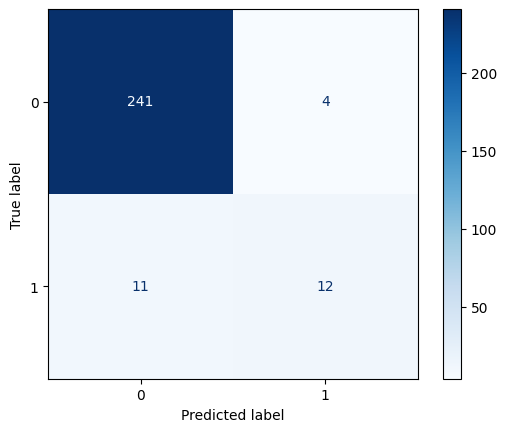

In [163]:
# Create confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
cmd1 = ConfusionMatrixDisplay.from_estimator(RF1, X_test1, y_test1, cmap='Blues')

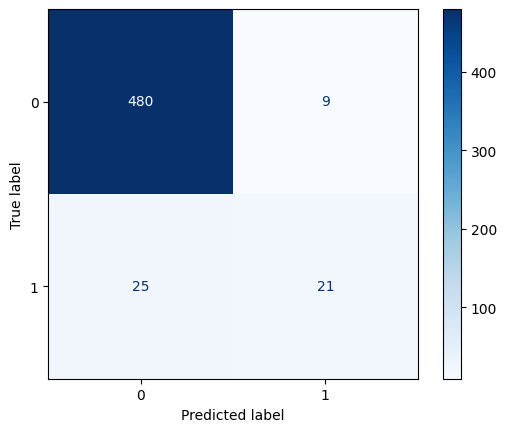

In [164]:
# Create confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
cmd2 = ConfusionMatrixDisplay.from_estimator(RF2, X_test2, y_test2, cmap='Blues')

**Current Results**

After initially experimenting with a KNN model and finding that the high ratio of false variables to positives in the dataset skewed it too hard I implemented random forest, which both had higher general accuracy and performed better in general. I believe pivoting towards non-linear models like this is the correct way forward, as they are able to handle much higher amounts of data and my current testing consistently yields higher accuracy than the logistic regression model that was employed prior. I believe my new method to clean and prepare data is more effective than the greedy algorithm used prior in respect to these nonlinear models, especially if I pursue machine learning to further develop the algorithm. In my remaining time on this project I'll spend more time tweaking the parameters of random forest to see if I can get better results and attempt to implement machine learning as a solution.

The random forest model seeing a notable boost in accuracy as well as a notable boost in correct classifications for people requiring emergency services when given a larger subset of the data to train also implies that more data to train on could be useful to take this further.

github link: https://github.com/Pot440/CSC-108-Final_Project